# Exploratory Data Analysis (EDA): Data Film & Data User
Notebook ini berisi Exploratory Data Analysis (EDA) untuk dua dataset:
1. `liked_netflix_movies_25m.csv`: Informasi detail mengenai film.
2. `user_like_netflix_movies_25m.csv`: Histori interaksi (likes) dari user terhadap film.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# Load data
# Dataset berada di folder DATA_FILM_with_USER
movies_df = pd.read_csv('DATA_FILM_with_USER/liked_netflix_movies_25m.csv')
users_df = pd.read_csv('DATA_FILM_with_USER/user_like_netflix_movies_25m.csv')

print(f"Shape of movies_df: {movies_df.shape}")
print(f"Shape of users_df: {users_df.shape}")

Shape of movies_df: (1195, 12)
Shape of users_df: (26152, 2)


## 1. EDA Data Film (`liked_netflix_movies_25m.csv`)
Mari kita lihat struktur data film, mengecek missing values, dan melihat distribusi dari beberapa kolom penting.

In [3]:
movies_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s39,Movie,Birth of the Dragon,George Nolfi,"Billy Magnussen, Ron Yuan, Qu Jingjing, Terry ...","China, Canada, United States","September 16, 2021",2017,PG-13,96 min,"Action & Adventure, Dramas",A young Bruce Lee angers kung fu traditionalis...
1,s95,Movie,Show Dogs,Raja Gosnell,"Will Arnett, Ludacris, Natasha Lyonne, Stanley...","United Kingdom, United States","September 8, 2021",2018,PG,90 min,"Children & Family Movies, Comedies",A rough and tough police dog must go undercove...
2,s97,Movie,If I Leave Here Tomorrow: A Film About Lynyrd ...,Stephen Kijak,"Ronnie Van Zandt, Gary Rossington, Allen Colli...",United States,"September 7, 2021",2018,TV-MA,97 min,"Documentaries, Music & Musicals","Using interviews and archival footage, this do..."
3,s134,Movie,Chappie,Neill Blomkamp,"Sharlto Copley, Hugh Jackman, Sigourney Weaver...","South Africa, United States","September 1, 2021",2015,R,121 min,"Action & Adventure, Sci-Fi & Fantasy",In a futuristic society where an indestructibl...
4,s142,Movie,Extraction,Steven C. Miller,"Bruce Willis, Kellan Lutz, Gina Carano, D.B. S...","United States, United Kingdom, Canada","September 1, 2021",2015,R,82 min,Action & Adventure,"When a retired CIA agent is kidnapped, his son..."


In [4]:
movies_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1195 entries, 0 to 1194
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       1195 non-null   object
 1   type          1195 non-null   object
 2   title         1195 non-null   object
 3   director      1167 non-null   object
 4   cast          1078 non-null   object
 5   country       1169 non-null   object
 6   date_added    1195 non-null   object
 7   release_year  1195 non-null   int64 
 8   rating        1195 non-null   object
 9   duration      1193 non-null   object
 10  listed_in     1195 non-null   object
 11  description   1195 non-null   object
dtypes: int64(1), object(11)
memory usage: 112.2+ KB


In [5]:
# Cek missing values
movies_df.isnull().sum()

show_id           0
type              0
title             0
director         28
cast            117
country          26
date_added        0
release_year      0
rating            0
duration          2
listed_in         0
description       0
dtype: int64

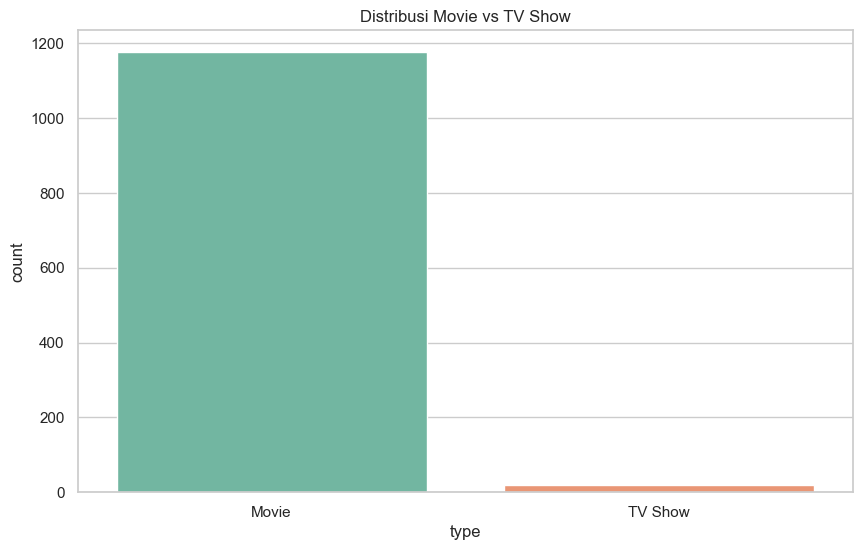

In [6]:

# Distribusi Tipe (Movie vs TV Show)
if 'type' in movies_df.columns:
    sns.countplot(data=movies_df, x='type', palette='Set2')
    plt.title('Distribusi Movie vs TV Show')
    plt.show()

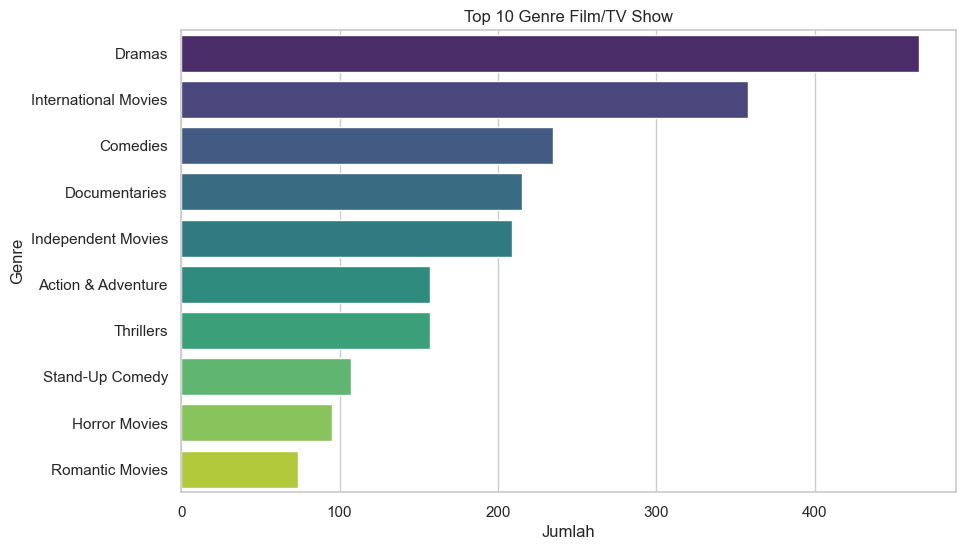

In [7]:
# Top 10 Genre (listed_in)
if 'listed_in' in movies_df.columns:
    # Memisahkan genre karena bisa lebih dari satu (dipisahkan koma)
    genres = movies_df['listed_in'].str.split(', ').explode()
    top_genres = genres.value_counts().head(10)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(y=top_genres.index, x=top_genres.values, palette='viridis')
    plt.title('Top 10 Genre Film/TV Show')
    plt.xlabel('Jumlah')
    plt.ylabel('Genre')
    plt.show()

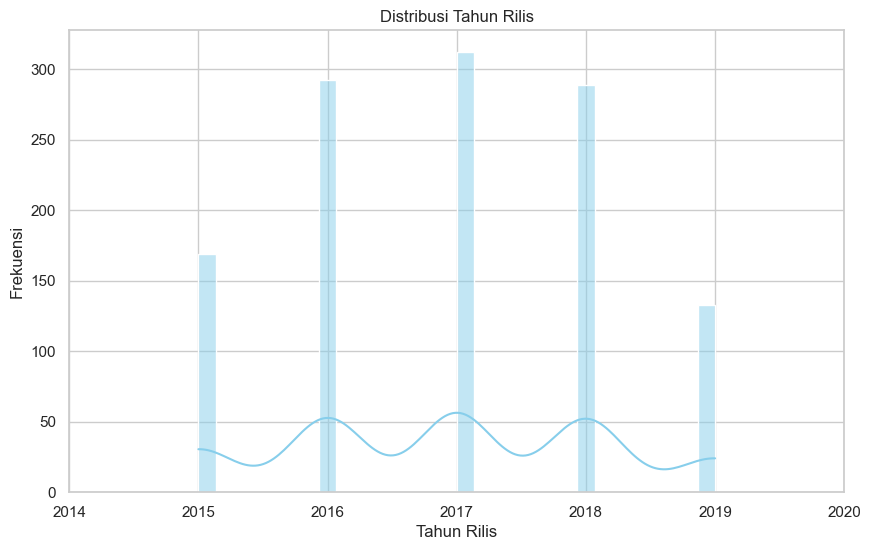

In [8]:
# Distribusi Tahun Rilis (Release Year)
if 'release_year' in movies_df.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(movies_df['release_year'], bins=30, kde=True, color='skyblue')
    plt.title('Distribusi Tahun Rilis')
    plt.xlabel('Tahun Rilis')
    plt.ylabel('Frekuensi')
    plt.xlim(2014, 2020) # Fokus pada tahun-tahun terbaru
    plt.show()

## 2. EDA Data User (`user_like_netflix_movies_25m.csv`)
Mari kita analisis interaksi user terhadap film.

In [9]:
users_df.head()

,user_id,show_id
0,294,s1285
1,294,s1334
2,294,s192
3,294,s2431
4,294,s2705


In [10]:
users_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26152 entries, 0 to 26151
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  26152 non-null  int64 
 1   show_id  26152 non-null  object
dtypes: int64(1), object(1)
memory usage: 408.8+ KB


In [11]:
# Jumlah user unik dan film unik yang berinteraksi
num_unique_users = users_df['user_id'].nunique()
num_unique_shows = users_df['show_id'].nunique()

print(f"Jumlah User Unik: {num_unique_users}")
print(f"Jumlah Film/Show Unik yang disukai: {num_unique_shows}")

Jumlah User Unik: 812
Jumlah Film/Show Unik yang disukai: 1195


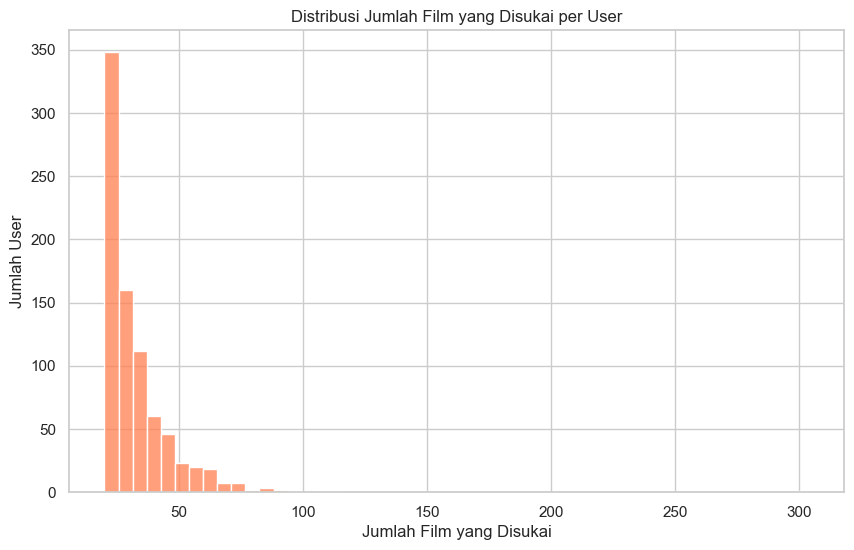

count    812.000000
mean      32.206897
std       16.428646
min       20.000000
25%       22.000000
50%       27.000000
75%       36.000000
max      304.000000
Name: show_id, dtype: float64


In [ ]:
# Distribusi jumlah likes per user (Berapa banyak film yang disukai oleh tiap user?)
likes_per_user = users_df.groupby('user_id')['show_id'].count()

plt.figure(figsize=(10, 6))
sns.histplot(likes_per_user, bins=50, color='coral')
plt.title('Distribusi Jumlah Film yang Disukai per User')
plt.xlabel('Jumlah Film yang Disukai')
plt.ylabel('Jumlah User')
plt.show()

print(likes_per_user.describe())

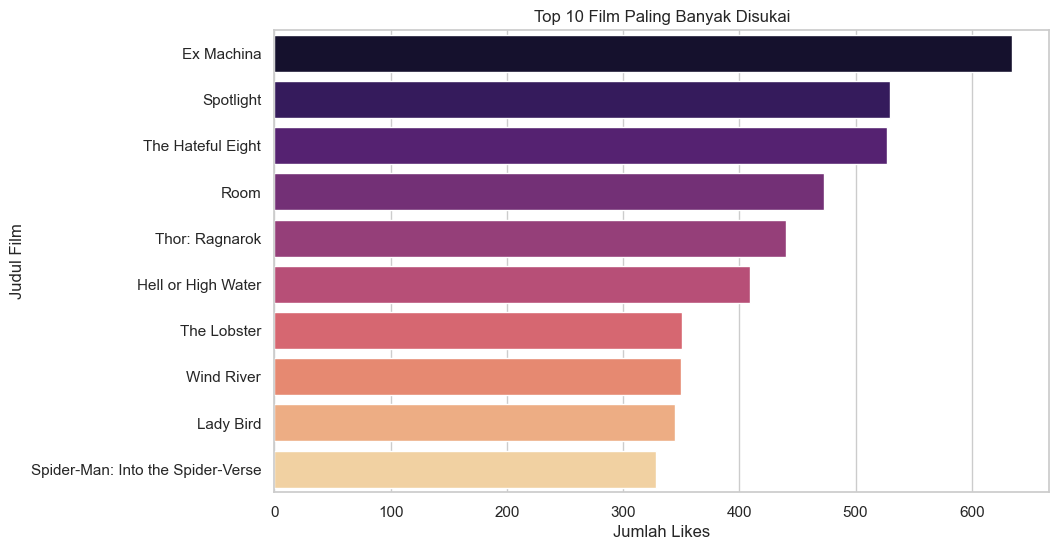

In [13]:
# Top 10 Film Paling Banyak Disukai
top_shows = users_df['show_id'].value_counts().head(10)

# Gabungkan dengan data film untuk mendapatkan judulnya
top_shows_df = top_shows.reset_index()
top_shows_df.columns = ['show_id', 'count']
top_shows_titles = top_shows_df.merge(movies_df[['show_id', 'title']], on='show_id')

plt.figure(figsize=(10, 6))
sns.barplot(y='title', x='count', data=top_shows_titles, palette='magma')
plt.title('Top 10 Film Paling Banyak Disukai')
plt.xlabel('Jumlah Likes')
plt.ylabel('Judul Film')
plt.show()